# K-Means Clustering 

## Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')

## Data Understanding

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Cleaning

#### Check Missing Values

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### Check Duplicate Values

In [8]:
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

#### Histogram + Mean Line + Skewness

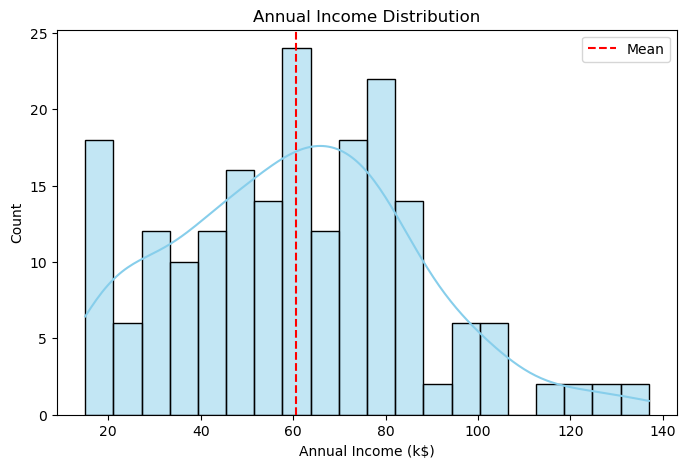

Skewness: 0.3218425498619055


In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='skyblue')
plt.axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Annual Income Distribution')
plt.legend()
plt.show()
print("Skewness:", df['Annual Income (k$)'].skew())

#### Spending Score Distribution

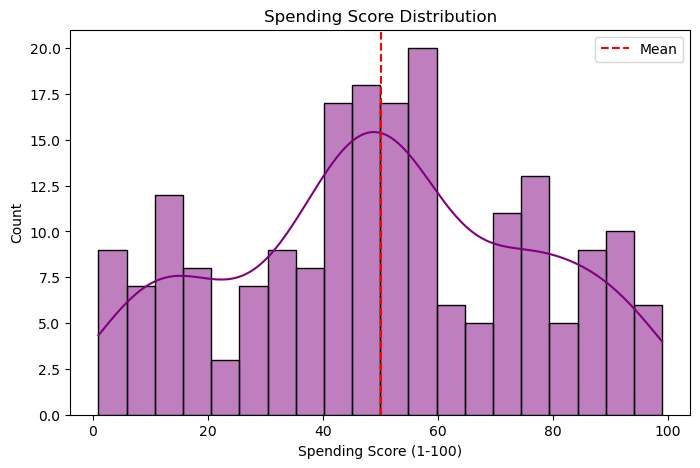

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='purple')
plt.axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Spending Score Distribution')
plt.legend()
plt.show()

##### Scatter Plot

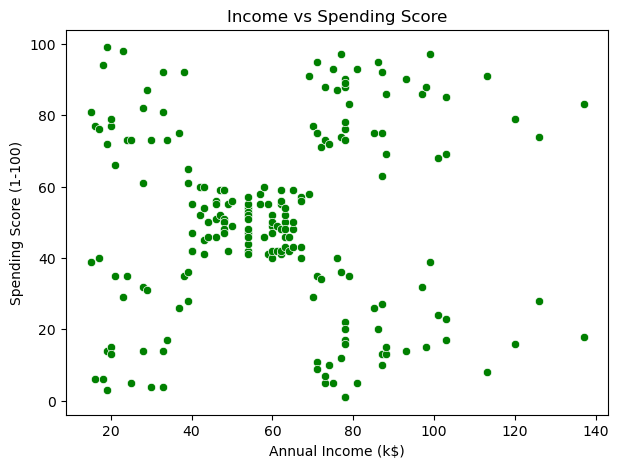

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, color='green')
plt.title('Income vs Spending Score')
plt.show()

#### Boxplot

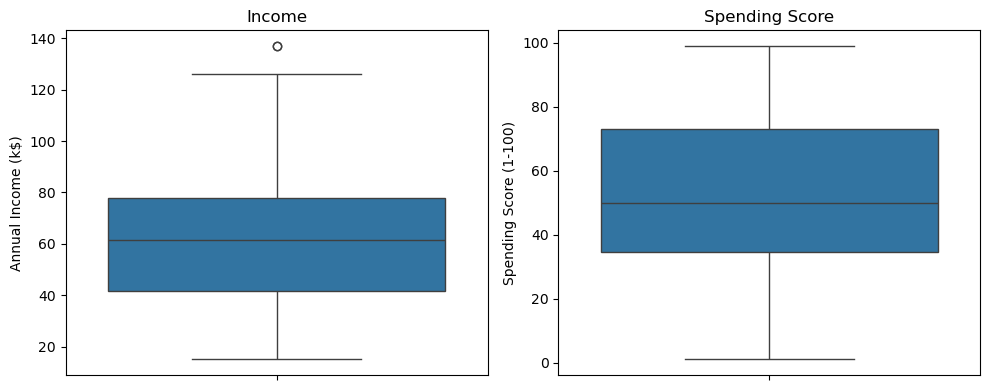

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['Annual Income (k$)'])
plt.title('Income')
plt.subplot(1,2,2)
sns.boxplot(y=df['Spending Score (1-100)'])
plt.title('Spending Score')
plt.tight_layout()
plt.show()

#### Correlation Heatmap

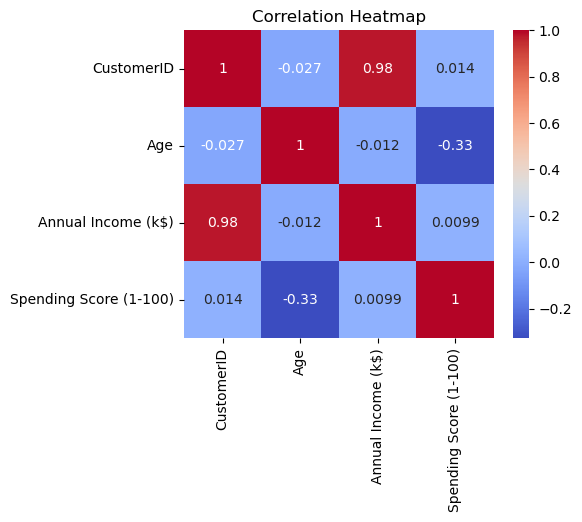

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering and Selection

#### Feature Engineering
Feature engineering is used to transform data into useful features for better analysis.

In [14]:
# Convert Gender into Numerical Values

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [15]:
# Create Income Category Feature

df['Income Category'] = pd.cut(df['Annual Income (k$)'], bins=[0,40,70,150], labels=['Low','Medium','High'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Category
0,1,0,19,15,39,Low
1,2,0,21,15,81,Low
2,3,1,20,16,6,Low
3,4,1,23,16,77,Low
4,5,1,31,17,40,Low


####  Feature Selection

Annual Income and Spending Score were selected for customer segmentation.

In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

#### Elbow Method

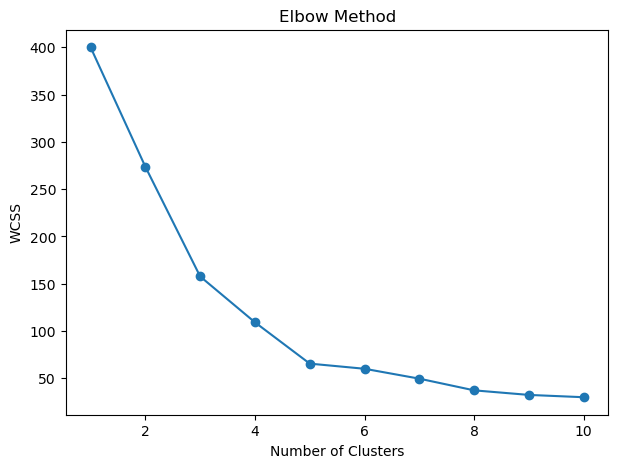

In [18]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Model Selection and Training

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income Category,Cluster
0,1,0,19,15,39,Low,4
1,2,0,21,15,81,Low,2
2,3,1,20,16,6,Low,4
3,4,1,23,16,77,Low,2
4,5,1,31,17,40,Low,4


#### Cluster Visualization

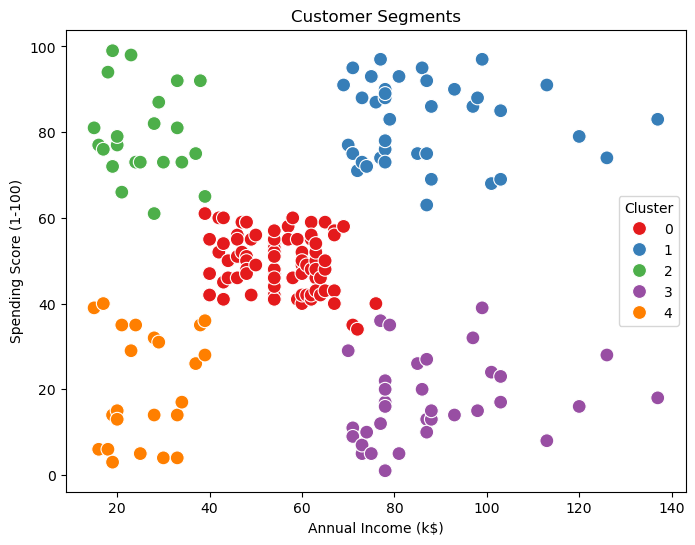

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='Set1', s=100)
plt.title('Customer Segments')
plt.show()

### Customer Segmentation Analysis
#### High Income + High Spending → Premium Customers
#### Low Income + Low Spending → Budget Customers
#### Average Income + Average Spending → Regular Customers

#### Model Evaluation

In [21]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


#### Model Deployment

In [22]:
import pickle
pickle.dump(kmeans, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


### Streamlit

In [23]:
import subprocess
import time

# Run Streamlit App
process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.headless", "true"]
)

# Wait for app to start
time.sleep(5)

# Show URL
print("✅ App running at: http://localhost:8501")

✅ App running at: http://localhost:8501
